# Лабораторная работа №2
## Обнаружение аномалий и выбросов в данных

**Датасет:** Gym Statistics DS

Данный датасет содержит ежедневные записи о посещаемости тренажерного зала, а также подробную информацию о тренировках: даты посещений, виды упражнений, продолжительность тренировок и количество сожжённых калорий.

In [1]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, skew, kurtosis
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
import statsmodels.api as sm
import warnings


---
# Задание 1. Загрузка и профилирование данных

In [6]:
df = pd.read_csv('../data/gym_statistic_ds.csv', sep=';')

df['visit_date'] = pd.to_datetime(df['visit_date'], format='%d.%m.%Y')
df['gender'] = df['gender'].astype('category')
df['membership_type'] = df['membership_type'].astype('category')
df['workout_type'] = df['workout_type'].astype('category')
df['check_in_time'] = pd.to_datetime(df['check_in_time'], format='%H:%M:%S').dt.time
df['attendance_status'] = df['attendance_status'].astype('category')

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер датасета: 2600 строк, 10 столбцов


In [27]:
# 2. df.info()
df.info()
print()
# 2. df.describe()
df.describe()
print()
# 3. Анализ пропусков
miss_data = pd.DataFrame({
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков, %': round((df.isnull().sum() / len(df) * 100), 2)
})
print(miss_data)

# 3. Анализ диапазонов значений и подозрительных экстремальных значений
numeric_cols = ['age', 'workout_duration_minutes', 'calories_burned']
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
    print(f"  Mean: {df[col].mean():.2f}, Std: {df[col].std():.2f}")
    print(f"  Медиана: {df[col].median()}")

# Подозрительные значения
print(f"\nПодозрительные значения:")
print(f"  Занятий с нулевым временем: {(df['workout_duration_minutes'] == 0).sum()}")
print(f"  Занятий с отрицательными калориями: {(df['calories_burned'] < 0).sum()}")
print(f"  Занятий с калориями > 1500: {(df['calories_burned'] > 1500).sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   member_id                 2600 non-null   int64         
 1   visit_date                2600 non-null   datetime64[us]
 2   age                       2600 non-null   int64         
 3   gender                    1737 non-null   category      
 4   membership_type           2600 non-null   category      
 5   workout_type              2600 non-null   category      
 6   workout_duration_minutes  2600 non-null   int64         
 7   calories_burned           2600 non-null   int64         
 8   check_in_time             2600 non-null   object        
 9   attendance_status         2600 non-null   category      
dtypes: category(4), datetime64[us](1), int64(4), object(1)
memory usage: 132.3+ KB


                          Количество пропусков  Доля пропусков, %
member_i

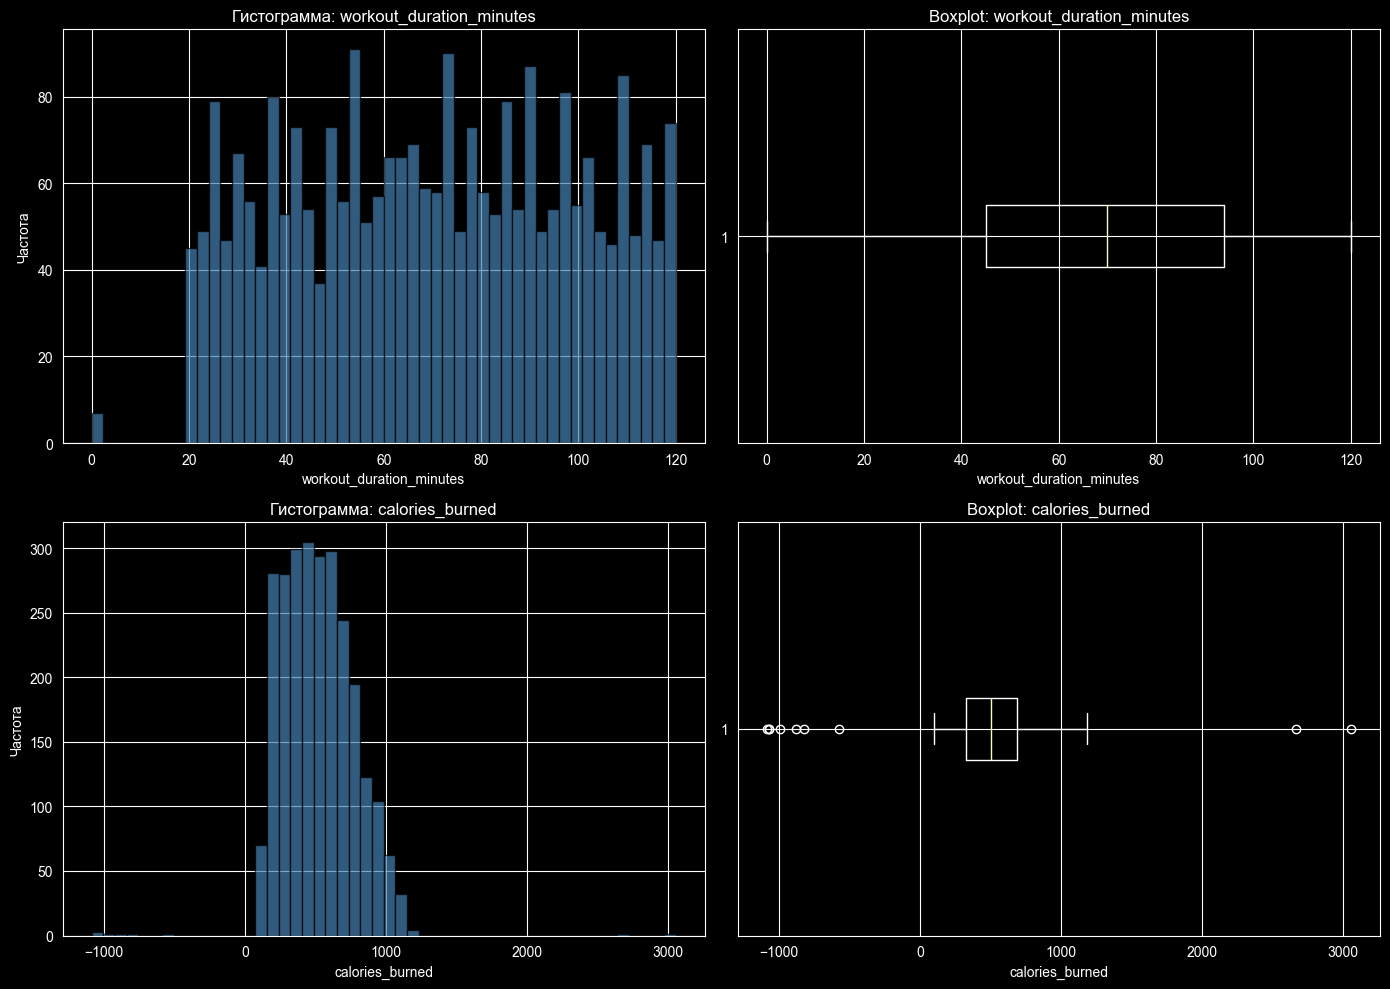

Вывод по визуальному анализу:

Выводы о возможных выбросах:
workout_duration_minutes (длительность тренировки):
Один выброс около 0 минут — вероятно, ошибочная запись или пропущенная тренировка
Остальные значения (20–120 мин) выглядят правдоподобно

calories_burned (сожжённые калории):
Отрицательные значения (~−1000) — физически невозможны, явно ошибочные данные
Экстремально высокие значения (~3000) — маловероятны для одной тренировки, возможные ошибки измерения
Оба типа выбросов требуют проверки и, скорее всего, удаления или коррекции


In [28]:
# Визуальный анализ двух числовых признаков: workout_duration_minutes и calories_burned
features = ['workout_duration_minutes', 'calories_burned']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(features):
    # Гистограмма
    axes[i, 0].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'Гистограмма: {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Частота')
    
    # Boxplot
    axes[i, 1].boxplot(df[col].dropna(), vert=False)
    axes[i, 1].set_title(f'Boxplot: {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylim(0.5, 1.5)

plt.tight_layout()
plt.show()

print("Вывод по визуальному анализу:")
print(
"""
Выводы о возможных выбросах:
workout_duration_minutes (длительность тренировки):
Один выброс около 0 минут — вероятно, ошибочная запись или пропущенная тренировка
Остальные значения (20–120 мин) выглядят правдоподобно

calories_burned (сожжённые калории):
Отрицательные значения (~−1000) — физически невозможны, явно ошибочные данные
Экстремально высокие значения (~3000) — маловероятны для одной тренировки, возможные ошибки измерения
Оба типа выбросов требуют проверки и, скорее всего, удаления или коррекции""")

---
# Задание 2. Проверка нормальности распределения

Выберем два числовых признака для детального анализа: **workout_duration_minutes** и **calories_burned**.

In [7]:
# 1. Описательные характеристики
for col in features:
    print(f"\n{'='*60}")
    print(f"Признак: {col}")
    print(f"{'='*60}")
    print(f"Среднее:           {df[col].mean():.4f}")
    print(f"Медиана:           {df[col].median():.4f}")
    print(f"Стд. отклонение:   {df[col].std():.4f}")
    print(f"Коэфф. асимметрии: {skew(df[col].dropna()):.4f}")
    print(f"Коэфф. эксцесса:   {kurtosis(df[col].dropna()):.4f}")


Признак: workout_duration_minutes
Среднее:           70.0146
Медиана:           70.0000
Стд. отклонение:   28.7970
Коэфф. асимметрии: -0.0328
Коэфф. эксцесса:   -1.1135

Признак: calories_burned
Среднее:           520.4846
Медиана:           502.5000
Стд. отклонение:   259.2749
Коэфф. асимметрии: 0.4014
Коэфф. эксцесса:   6.8800


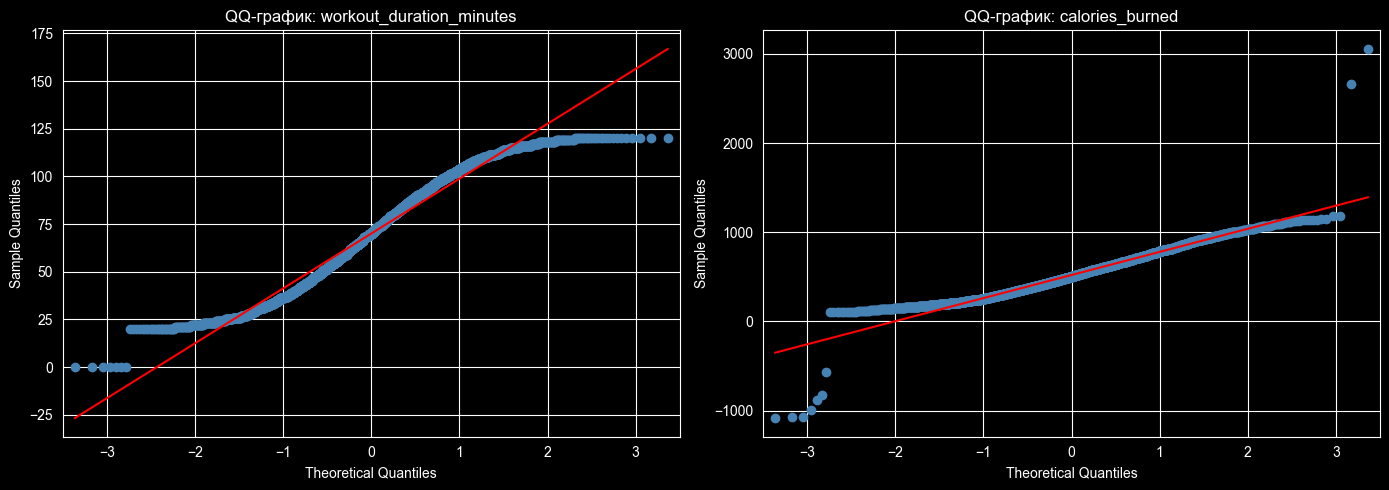

In [8]:
# 2. QQ-график
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(features):
    sm.qqplot(df[col].dropna(), line='s', ax=axes[i], markerfacecolor='steelblue', markeredgecolor='steelblue')
    axes[i].set_title(f'QQ-график: {col}')

plt.tight_layout()
plt.show()

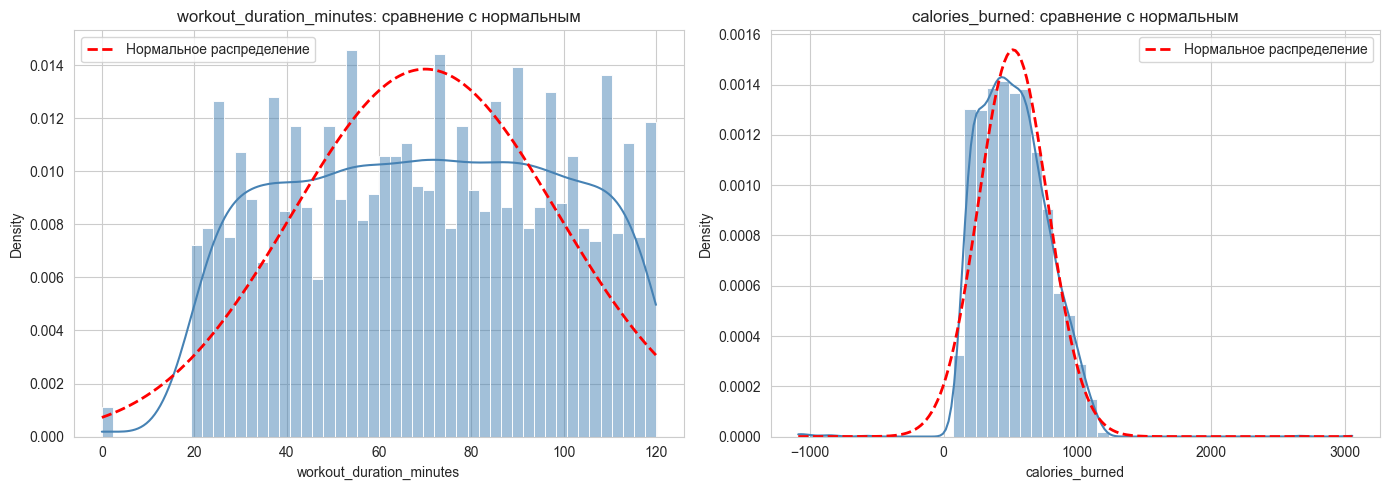

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(features):
    data = df[col].dropna()
    mu, sigma = data.mean(), data.std()
    
    sns.histplot(data, kde=True, stat='density', bins=50, color='steelblue', ax=axes[i])
    x = np.linspace(data.min(), data.max(), 200)
    axes[i].plot(x, stats.norm.pdf(x, mu, sigma), 'r--', linewidth=2, label='Нормальное распределение')
    axes[i].set_title(f'{col}: сравнение с нормальным')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [9]:
np.random.seed(42)
sample_size = min(5000, len(df))

for col in features:
    sample = df[col].dropna().sample(n=sample_size, random_state=42)
    stat, p_value = shapiro(sample)
    
    print(f"\n{'='*60}")
    print(f"Признак: {col}")
    print(f"{'='*60}")
    print(f"Статистика Шапиро-Уилка: {stat:.6f}")
    print(f"p-value: {p_value:.10f}")
    print(f"Уровень значимости α = 0.05")
    
    if p_value > 0.05:
        print(f"Вывод: p-value ({p_value:.6f}) > 0.05 => Нет оснований отвергнуть H0.")
        print(f"       Выборка ПОДЧИНЯЕТСЯ нормальному распределению.")
    else:
        print(f"Вывод: p-value ({p_value:.6f}) < 0.05 => Отвергаем H0.")
        print(f"       Выборка НЕ подчиняется нормальному распределению.")


Признак: workout_duration_minutes
Статистика Шапиро-Уилка: 0.962988
p-value: 0.0000000000
Уровень значимости α = 0.05
Вывод: p-value (0.000000) < 0.05 => Отвергаем H0.
       Выборка НЕ подчиняется нормальному распределению.

Признак: calories_burned
Статистика Шапиро-Уилка: 0.937218
p-value: 0.0000000000
Уровень значимости α = 0.05
Вывод: p-value (0.000000) < 0.05 => Отвергаем H0.
       Выборка НЕ подчиняется нормальному распределению.


---
# Задание 3. Обнаружение выбросов статистическими методами

Для признака, распределение которого **ближе к нормальному**, применим методы Z-score и IQR.
По результатам задания 2, **workout_duration_minutes** ближе к нормальному распределению, чем calories_burned.

In [11]:
# === Метод Z-score ===
col = 'calories_burned'
data = df[col].dropna()
z_scores = np.abs(stats.zscore(data))
outliers_z = data[z_scores > 3]

print(f"Метод Z-score для признака '{col}'")
print(f"{'='*50}")
print(f"Всего наблюдений: {len(data)}")
print(f"Количество выбросов (|Z| > 3): {len(outliers_z)} ({len(outliers_z)/len(data)*100:.2f}%)")
if len(outliers_z) > 0:
    print(f"Минимальное значение выброса: {outliers_z.min()}")
    print(f"Максимальное значение выброса: {outliers_z.max()}")

Метод Z-score для признака 'calories_burned'
Всего наблюдений: 2600
Количество выбросов (|Z| > 3): 9 (0.35%)
Минимальное значение выброса: -1086
Максимальное значение выброса: 3056


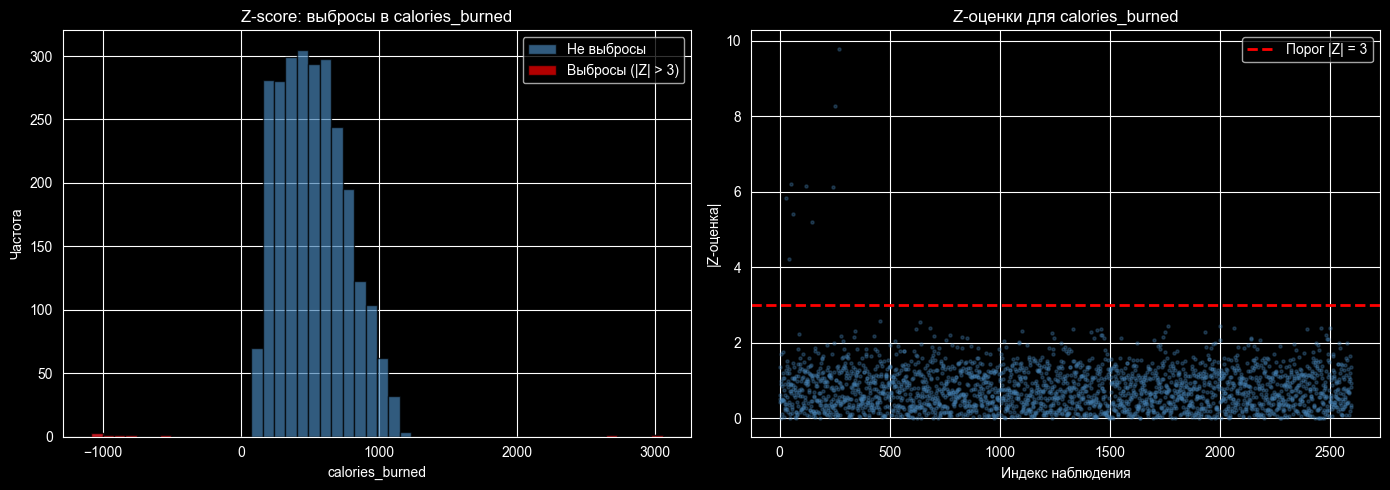

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7, label='Не выбросы')
if len(outliers_z) > 0:
    axes[0].hist(outliers_z, bins=50, color='red', edgecolor='black', alpha=0.7, label='Выбросы (|Z| > 3)')
axes[0].set_title(f'Z-score: выбросы в {col}')
axes[0].set_xlabel(col)
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].scatter(range(len(z_scores)), z_scores, alpha=0.3, s=5, color='steelblue')
axes[1].axhline(y=3, color='r', linestyle='--', linewidth=2, label='Порог |Z| = 3')
axes[1].set_title(f'Z-оценки для {col}')
axes[1].set_xlabel('Индекс наблюдения')
axes[1].set_ylabel('|Z-оценка|')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]

print(f"Метод IQR для признака '{col}'")
print(f"{'='*50}")
print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"\nКоличество выбросов: {len(outliers_iqr)} ({len(outliers_iqr)/len(data)*100:.2f}%)")
if len(outliers_iqr) > 0:
    print(f"Минимальное значение выброса: {outliers_iqr.min()}")
    print(f"Максимальное значение выброса: {outliers_iqr.max()}")

Метод IQR для признака 'calories_burned'
Q1 = 326.75
Q3 = 690.0
IQR = 363.25
Нижняя граница: -218.12
Верхняя граница: 1234.88

Количество выбросов: 9 (0.35%)
Минимальное значение выброса: -1086
Максимальное значение выброса: 3056


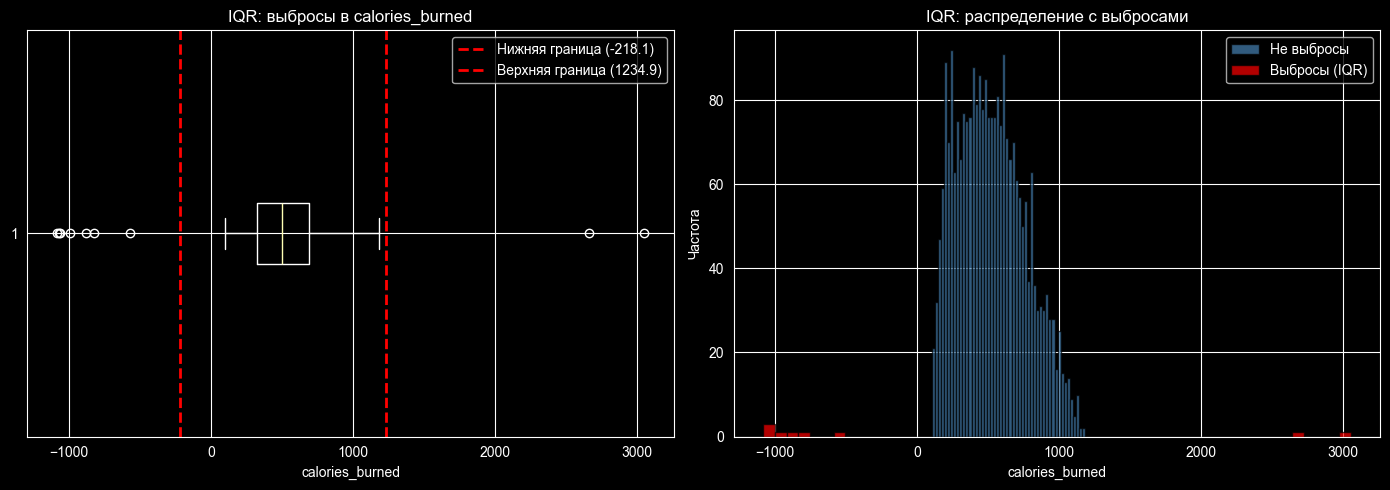

In [14]:
# Визуализация IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(data, vert=False)
axes[0].axvline(x=lower_bound, color='r', linestyle='--', linewidth=2, label=f'Нижняя граница ({lower_bound:.1f})')
axes[0].axvline(x=upper_bound, color='r', linestyle='--', linewidth=2, label=f'Верхняя граница ({upper_bound:.1f})')
axes[0].set_title(f'IQR: выбросы в {col}')
axes[0].set_xlabel(col)
axes[0].legend()

non_outliers = data[(data >= lower_bound) & (data <= upper_bound)]
axes[1].hist(non_outliers, bins=50, color='steelblue', edgecolor='black', alpha=0.7, label='Не выбросы')
if len(outliers_iqr) > 0:
    axes[1].hist(outliers_iqr, bins=50, color='red', edgecolor='black', alpha=0.7, label='Выбросы (IQR)')
axes[1].set_title(f'IQR: распределение с выбросами')
axes[1].set_xlabel(col)
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# === Сравнительный анализ методов ===
print(f"Сравнительный анализ методов для '{col}'")
print(f"{'='*60}")
print(f"{'Метод':<20} {'Выбросов':<15} {'Процент':<15}")
print(f"{'-'*60}")
print(f"{'Z-score (|Z|>3)':<20} {len(outliers_z):<15} {len(outliers_z)/len(data)*100:<15.2f}")
print(f"{'IQR (1.5*IQR)':<20} {len(outliers_iqr):<15} {len(outliers_iqr)/len(data)*100:<15.2f}")
print()

# Пересечение выбросов
outliers_z_idx = set(data[z_scores > 3].index)
outliers_iqr_idx = set(outliers_iqr.index)
common = outliers_z_idx & outliers_iqr_idx
only_z = outliers_z_idx - outliers_iqr_idx
only_iqr = outliers_iqr_idx - outliers_z_idx

print(f"Общие выбросы (оба метода): {len(common)}")
print(f"Только Z-score: {len(only_z)}")
print(f"Только IQR: {len(only_iqr)}")


Сравнительный анализ методов для 'calories_burned'
Метод                Выбросов        Процент        
------------------------------------------------------------
Z-score (|Z|>3)      9               0.35           
IQR (1.5*IQR)        9               0.35           

Общие выбросы (оба метода): 9
Только Z-score: 0
Только IQR: 0


---
# Задание 4. Метод локальной плотности (LOF-подход на основе k-NN)

Аномалия — это объект, находящийся в области низкой плотности по сравнению с окружающими объектами.

Будем использовать два числовых признака: **workout_duration_minutes** и **calories_burned**.
Предварительно выполним масштабирование признаков.

In [8]:
df_analysis = df[['workout_duration_minutes', 'calories_burned']].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_analysis)

print(f"Размер выборки для k-NN анализа: {X_scaled.shape[0]} объектов, {X_scaled.shape[1]} признака")
print(f"Признаки после масштабирования: mean ≈ 0, std ≈ 1")

Размер выборки для k-NN анализа: 2600 объектов, 2 признака
Признаки после масштабирования: mean ≈ 0, std ≈ 1


In [9]:
# Функция для вычисления метрик на основе k-NN
def compute_knn_metrics(X, k, metric='euclidean'):

    nn = NearestNeighbors(n_neighbors=k+1, metric=metric) 
    nn.fit(X)
    distances, indices = nn.kneighbors(X)
    
    neighbor_distances = distances[:, 1:]
    
    # Расстояние до k-го соседа
    kth_distance = neighbor_distances[:, -1]
    # Среднее расстояние до k соседей
    mean_distance = neighbor_distances.mean(axis=1)
    # Локальная плотность
    local_density = 1.0 / (mean_distance + 1e-10)
    
    return kth_distance, mean_distance, local_density

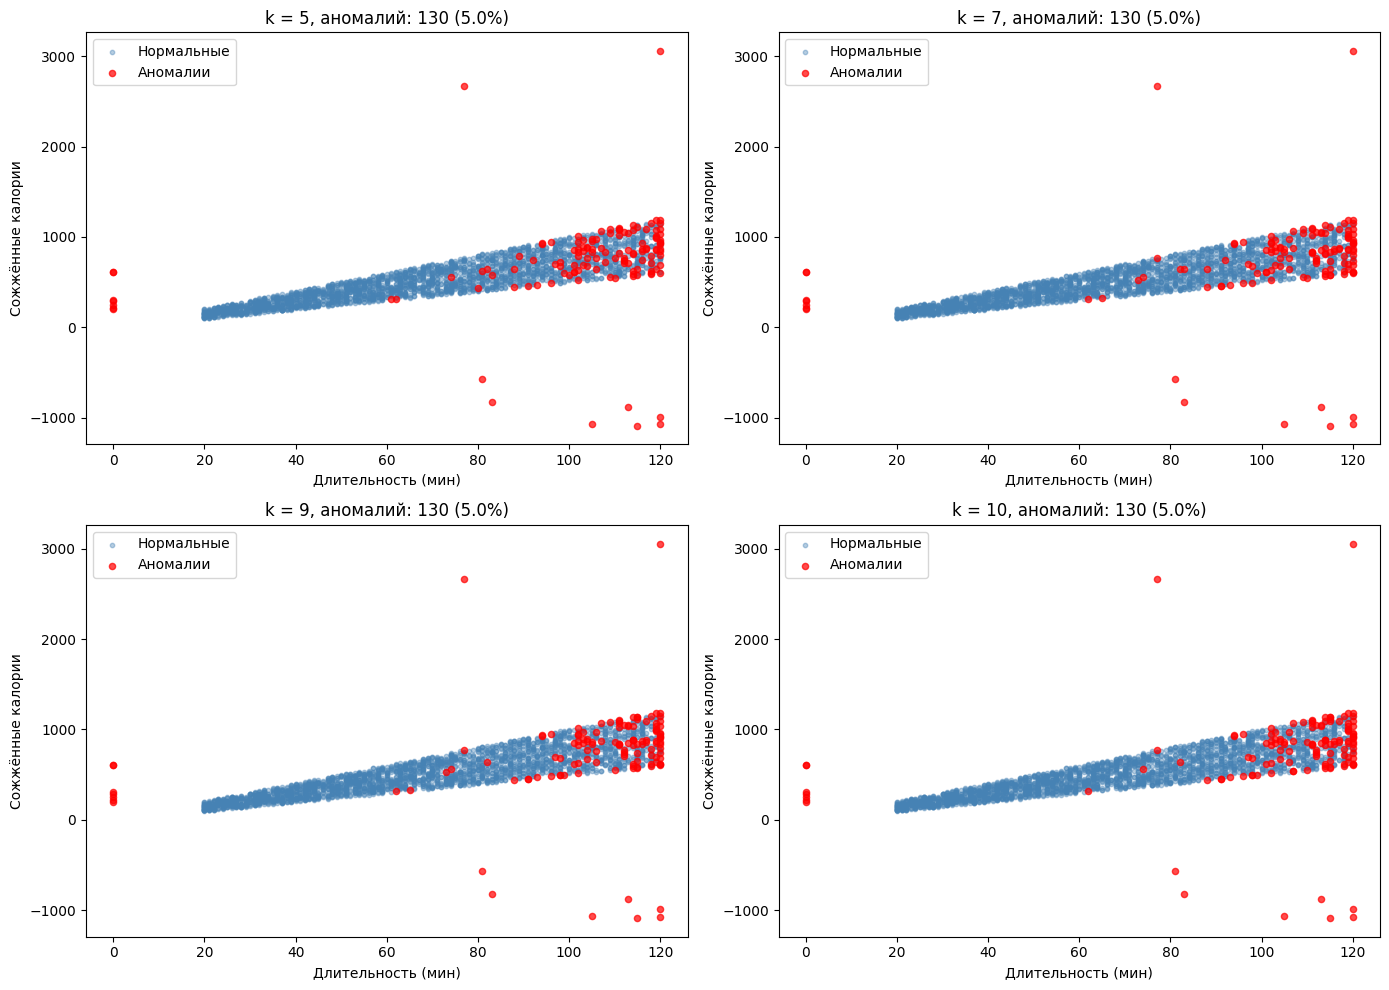

In [10]:
# Вычисление для k = 5, 7, 9, 10 с Евклидовым расстоянием
k_values = [5, 7, 9, 10]
alpha = 5

results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    kth_dist, mean_dist, density = compute_knn_metrics(X_scaled, k, metric='euclidean')
    
    threshold = np.percentile(mean_dist, 100 - alpha)
    anomaly_mask = mean_dist > threshold
    
    results[k] = {
        'kth_distance': kth_dist,
        'mean_distance': mean_dist,
        'local_density': density,
        'threshold': threshold,
        'anomaly_mask': anomaly_mask,
        'n_anomalies': anomaly_mask.sum()
    }
    
    normal = df_analysis[~anomaly_mask]
    anomalies = df_analysis[anomaly_mask]
    
    axes[idx].scatter(normal['workout_duration_minutes'], normal['calories_burned'],
                     alpha=0.4, s=10, color='steelblue', label='Нормальные')
    axes[idx].scatter(anomalies['workout_duration_minutes'], anomalies['calories_burned'],
                     alpha=0.7, s=20, color='red', label='Аномалии')
    axes[idx].set_title(f'k = {k}, аномалий: {anomaly_mask.sum()} ({anomaly_mask.sum()/len(df_analysis)*100:.1f}%)')
    axes[idx].set_xlabel('Длительность (мин)')
    axes[idx].set_ylabel('Сожжённые калории')
    axes[idx].legend()

plt.tight_layout()
plt.show()

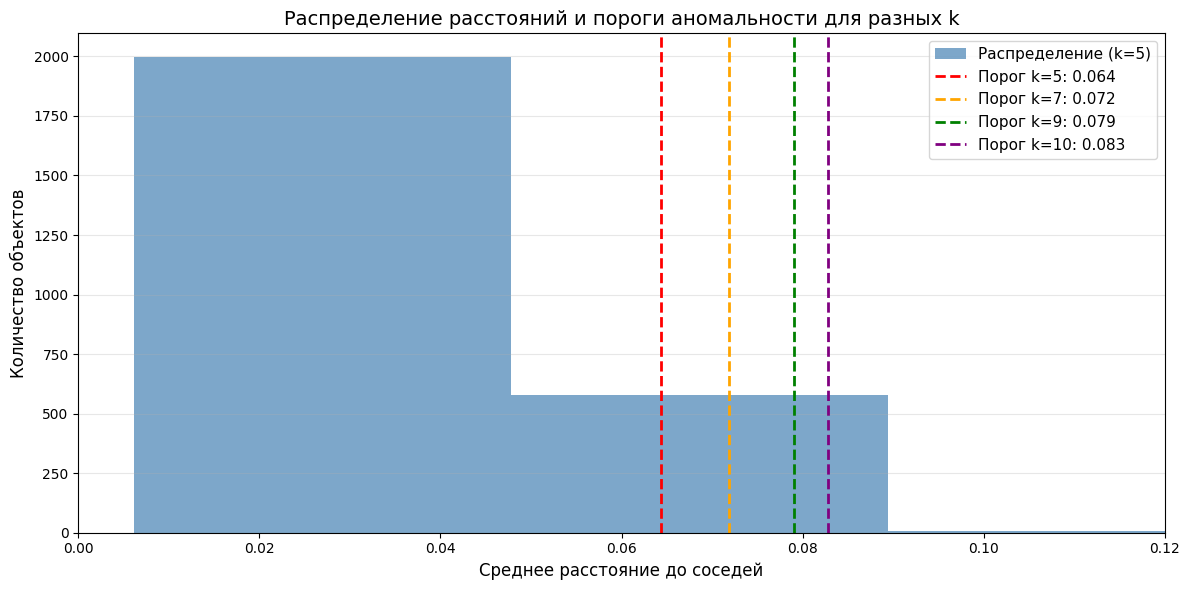

In [ ]:
plt.figure(figsize=(12, 6))

k_base = 5
kth_dist, mean_dist, local_density = compute_knn_metrics(X_scaled, k_base)
plt.hist(mean_dist, bins=150, color='steelblue', alpha=0.7, label=f'Распределение (k={k_base})')

k_values = [5, 7, 9, 10]
colors = ['red', 'orange', 'green', 'purple']

for k, color in zip(k_values, colors):
    _, mean_dist_k, _ = compute_knn_metrics(X_scaled, k)
    threshold = np.percentile(mean_dist_k, 100 - alpha_level)
    plt.axvline(x=threshold, color=color, linestyle='--', linewidth=2, 
                label=f'Порог k={k}: {threshold:.3f}')

# Настройки отображения
plt.title('Распределение расстояний и пороги аномальности для разных k', fontsize=14)
plt.xlabel('Среднее расстояние до соседей', fontsize=12)
plt.ylabel('Количество объектов', fontsize=12)
plt.legend(fontsize=11)

plt.xlim(0, 0.12) 
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Сравнение метрик: Евклидово vs Манхэттенское расстояние
k= 5 | Евклидово:  130 аномалий | Манхэттенское:  130 аномалий
k= 7 | Евклидово:  130 аномалий | Манхэттенское:  130 аномалий
k= 9 | Евклидово:  130 аномалий | Манхэттенское:  130 аномалий
k=10 | Евклидово:  130 аномалий | Манхэттенское:  130 аномалий


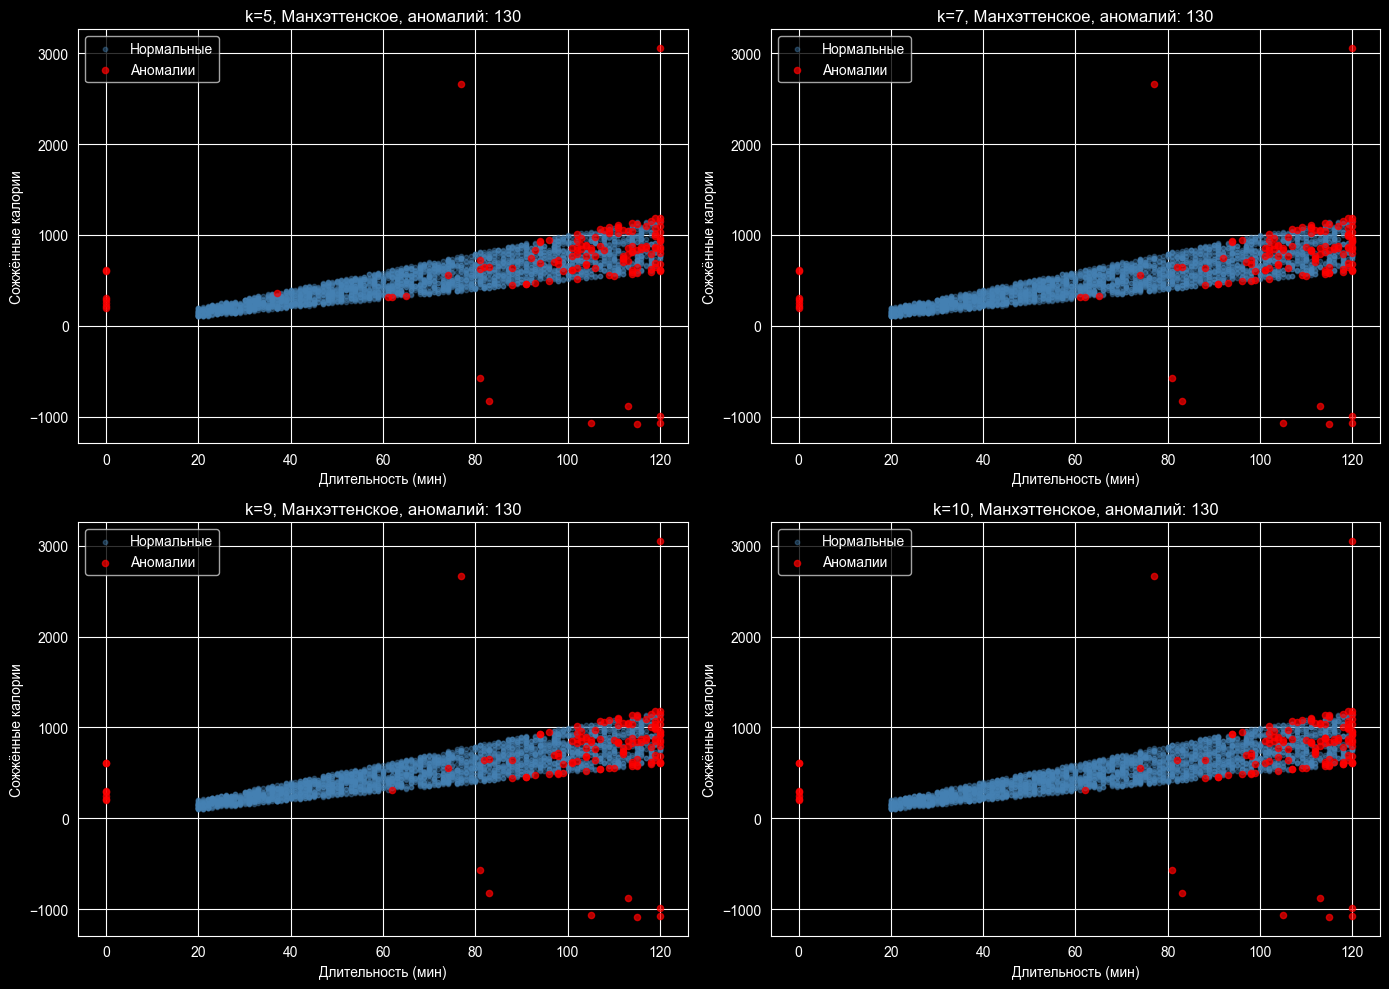

In [23]:
# Сравнение с Манхэттенским расстоянием
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print(f"\n{'='*70}")
print(f"Сравнение метрик: Евклидово vs Манхэттенское расстояние")
print(f"{'='*70}")

for idx, k in enumerate(k_values):
    # Манхэттенское расстояние
    kth_dist_m, mean_dist_m, density_m = compute_knn_metrics(X_scaled, k, metric='manhattan')
    
    threshold_m = np.percentile(mean_dist_m, 100 - alpha)
    anomaly_mask_m = mean_dist_m > threshold_m
    
    normal_m = df_analysis[~anomaly_mask_m]
    anomalies_m = df_analysis[anomaly_mask_m]
    
    axes[idx].scatter(normal_m['workout_duration_minutes'], normal_m['calories_burned'],
                     alpha=0.4, s=10, color='steelblue', label='Нормальные')
    axes[idx].scatter(anomalies_m['workout_duration_minutes'], anomalies_m['calories_burned'],
                     alpha=0.7, s=20, color='red', label='Аномалии')
    axes[idx].set_title(f'k={k}, Манхэттенское, аномалий: {anomaly_mask_m.sum()}')
    axes[idx].set_xlabel('Длительность (мин)')
    axes[idx].set_ylabel('Сожжённые калории')
    axes[idx].legend()
    
    print(f"k={k:2d} | Евклидово: {results[k]['n_anomalies']:4d} аномалий | "
          f"Манхэттенское: {anomaly_mask_m.sum():4d} аномалий")

plt.tight_layout()
plt.show()

In [24]:
# Сводная таблица по устойчивости метода при изменении k
print(f"\n{'='*70}")
print(f"Анализ устойчивости метода при изменении k (Евклидово расстояние)")
print(f"{'='*70}")
print(f"{'k':<5} {'Аномалий':<12} {'Процент':<12} {'Порог сред. расст.':<22}")
print(f"{'-'*70}")

for k in k_values:
    r = results[k]
    print(f"{k:<5} {r['n_anomalies']:<12} {r['n_anomalies']/len(df_analysis)*100:<12.2f} {r['threshold']:<22.6f}")

# Проверка стабильности: насколько одни и те же точки определяются как аномалии
print(f"\nПересечение аномалий между разными k:")
anomaly_sets = {k: set(df_analysis.index[results[k]['anomaly_mask']]) for k in k_values}

for i, k1 in enumerate(k_values):
    for k2 in k_values[i+1:]:
        intersection = anomaly_sets[k1] & anomaly_sets[k2]
        union = anomaly_sets[k1] | anomaly_sets[k2]
        jaccard = len(intersection) / len(union) if len(union) > 0 else 0
        print(f"  k={k1} ∩ k={k2}: {len(intersection)} общих, Jaccard = {jaccard:.4f}")
        


Анализ устойчивости метода при изменении k (Евклидово расстояние)
k     Аномалий     Процент      Порог сред. расст.    
----------------------------------------------------------------------
5     130          5.00         0.064340              
7     130          5.00         0.071902              
9     130          5.00         0.079080              
10    130          5.00         0.082826              

Пересечение аномалий между разными k:
  k=5 ∩ k=7: 110 общих, Jaccard = 0.7333
  k=5 ∩ k=9: 103 общих, Jaccard = 0.6561
  k=5 ∩ k=10: 103 общих, Jaccard = 0.6561
  k=7 ∩ k=9: 121 общих, Jaccard = 0.8705
  k=7 ∩ k=10: 117 общих, Jaccard = 0.8182
  k=9 ∩ k=10: 126 общих, Jaccard = 0.9403
